Original Image
      ↓
Resize to 224 × 224
      ↓
Convert to Tensor
      ↓
Normalize using ImageNet statistics
      ↓
Ready for DenseNet121

In [2]:
import torch
from torchvision import transforms, datasets
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = Path("..")

DATASET_DIR = BASE_DIR / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

print("Train directory exists:", TRAIN_DIR.exists())
print("Validation directory exists:", VAL_DIR.exists())

Train directory exists: True
Validation directory exists: True


In [4]:
preprocess_transform = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=preprocess_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=preprocess_transform
)

In [6]:
print("Train mapping:")
print(train_dataset.class_to_idx)

print("\nValidation mapping:")
print(val_dataset.class_to_idx)

Train mapping:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Validation mapping:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [7]:
assert train_dataset.class_to_idx == val_dataset.class_to_idx

print("PASS: Class mappings are identical.")

PASS: Class mappings are identical.


In [8]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label index:", label)
print("Class name:", train_dataset.classes[label])
print("Data type:", image.dtype)

Image shape: torch.Size([3, 224, 224])
Label index: 0
Class name: akiec
Data type: torch.float32


In [9]:
def denormalize(image):
    
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)
    
    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)
    
    return image * std + mean

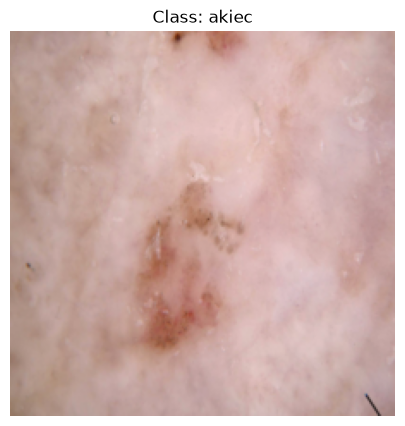

In [10]:
image, label = train_dataset[0]

display_image = denormalize(image)

display_image = display_image.permute(1, 2, 0)

display_image = torch.clamp(
    display_image,
    0,
    1
)

plt.figure(figsize=(5, 5))

plt.imshow(display_image)

plt.title(
    f"Class: {train_dataset.classes[label]}"
)

plt.axis("off")

plt.show()

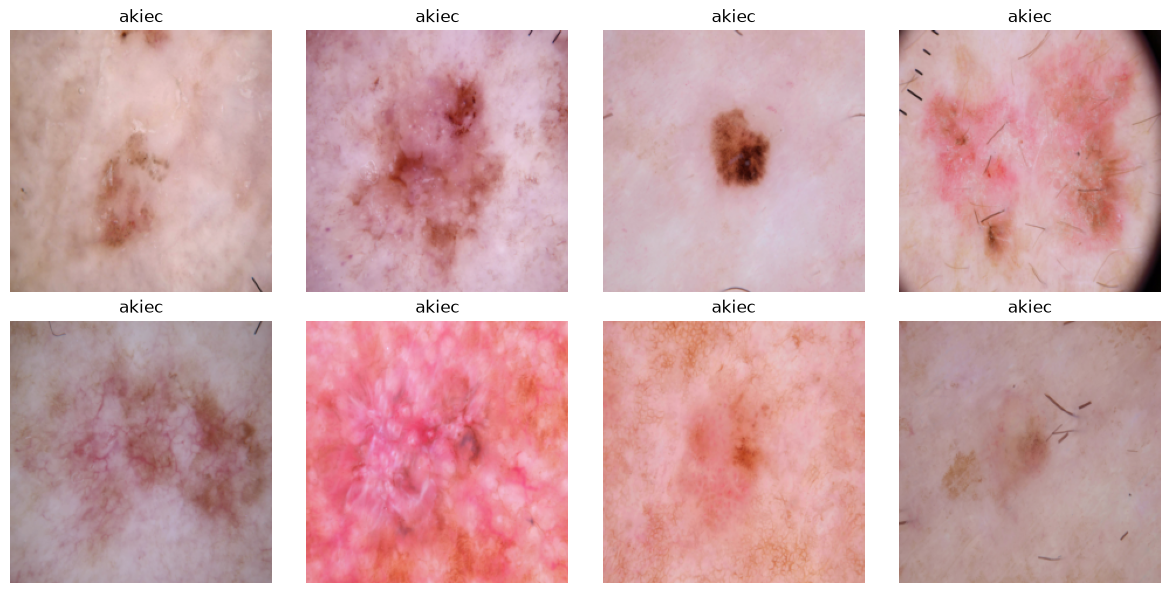

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, index in zip(axes.flat, range(8)):
    
    image, label = train_dataset[index]
    
    image = denormalize(image)
    
    image = image.permute(1, 2, 0)
    
    image = torch.clamp(image, 0, 1)
    
    ax.imshow(image)
    
    ax.set_title(
        train_dataset.classes[label]
    )
    
    ax.axis("off")

plt.tight_layout()

plt.show()

In [12]:
assert len(train_dataset) == 8017
assert len(val_dataset) == 1998

assert (
    train_dataset.class_to_idx
    ==
    val_dataset.class_to_idx
)

image, label = train_dataset[0]

assert image.shape == (3, 224, 224)
assert image.dtype == torch.float32

print("=" * 55)
print("PHASE 8 COMPLETED SUCCESSFULLY")
print("=" * 55)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Input shape:", image.shape)
print("Classes:", train_dataset.classes)

print("\nDataset is ready for augmentation and DataLoader creation.")

PHASE 8 COMPLETED SUCCESSFULLY
Training images: 8017
Validation images: 1998
Input shape: torch.Size([3, 224, 224])
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Dataset is ready for augmentation and DataLoader creation.
